# Notebook 05 – Default UI Repository

Build the **default UI repository** directly from the cleaned survey.

- No machine learning
- No association rules
- No clustering

For every UI element, the default is the **majority preference** (most selected option).
These defaults are the base interface the website loads before applying any adaptations.

## Expected Outputs

**JSON (website):**
- `data/outputs/global_defaults.json`
- `data/outputs/desktop_defaults.json`
- `data/outputs/mobile_defaults.json`

**Tables / figures:**
- `reports/DefaultUI/global_defaults.xlsx`
- `reports/DefaultUI/desktop_defaults.xlsx`
- `reports/DefaultUI/mobile_defaults.xlsx`
- `reports/DefaultUI/figures/`

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _bootstrap_project() -> Path:
    search_from = Path.cwd().resolve()
    candidates = [search_from, *search_from.parents]
    nested_root = search_from / "EvidenceBasedAdaptiveUI"
    if (nested_root / "src" / "config.py").exists():
        candidates.insert(0, nested_root)
    for candidate in candidates:
        if (candidate / "src" / "config.py").exists():
            root = str(candidate)
            if root not in sys.path:
                sys.path.insert(0, root)
            return candidate
    raise FileNotFoundError("Could not find project root containing src/config.py.")


PROJECT_ROOT = _bootstrap_project()

from src.default_ui.repository import run_default_ui_repository
from src.preprocessing.columns import (
    DESKTOP_UI_COLUMNS,
    GLOBAL_UI_COLUMNS,
    MOBILE_UI_COLUMNS,
)
from src.utils.notebook import setup_notebook

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)
plt.rcParams["figure.dpi"] = 200

PATHS, REPORTS = setup_notebook("DefaultUI")
OUTPUT_DIR = PATHS.data_outputs

print(f"Reports: {REPORTS}")
print(f"JSON output: {OUTPUT_DIR}")

Reports: /Users/mariam/Downloads/New_Master copy/smartshop/EvidenceBasedAdaptiveUI/reports/DefaultUI
JSON output: /Users/mariam/Downloads/New_Master copy/smartshop/EvidenceBasedAdaptiveUI/data/outputs


## Load Clean Dataset

In [2]:
df = pd.read_csv(PATHS.data_processed / "clean_dataset.csv")
print(f"Respondents: {len(df)}")
display(df.head(3))

Respondents: 224


,timestamp,consent,age_group,gender,education_level,primary_device,shopping_motivation,decision_speed,price_sensitivity,review_importance,...,Extraversion,Agreeableness,Conscientiousness,Neuroticism,Openness,Extraversion_Level,Agreeableness_Level,Conscientiousness_Level,Neuroticism_Level,Openness_Level
0,20/01/2026 17:24:30,Yes,18-24,Male,Graduate,Smartphone,Research (I like exploring products and learni...,Quick (5-15 minutes - I know what I want),Moderately important (I balance price and qual...,Sometimes read reviews (For certain product ty...,...,3.0,3.0,3.0,3.0,3.0,Medium,Medium,Medium,Medium,Medium
1,20/01/2026 17:27:08,Yes,25-34,Female,Graduate,Smartphone,Deal-hunting (I look for sales and discounts),Moderate (15-30 minutes - I compare a few opti...,Moderately important (I balance price and qual...,Often read reviews (For most purchases),...,3.5,4.5,3.5,2.5,2.5,Medium,High,Medium,Low,Low
2,20/01/2026 17:37:31,Yes,25-34,Female,Graduate,Smartphone,Gift-buying (I mainly shop for others),Moderate (15-30 minutes - I compare a few opti...,Moderately important (I balance price and qual...,Always read reviews (I won't buy without check...,...,4.0,3.0,4.5,5.0,4.0,High,Medium,High,High,High


## Step 1 — Separate UI Variables

Global UI · Desktop UI · Mobile UI

In [3]:
print(f"Global UI variables ({len(GLOBAL_UI_COLUMNS)}):")
for column in GLOBAL_UI_COLUMNS:
    print(f"  - {column}")

print(f"\nDesktop UI variables ({len(DESKTOP_UI_COLUMNS)}):")
for column in DESKTOP_UI_COLUMNS:
    print(f"  - {column}")

print(f"\nMobile UI variables ({len(MOBILE_UI_COLUMNS)}):")
for column in MOBILE_UI_COLUMNS:
    print(f"  - {column}")

Global UI variables (14):
  - font_style_pref
  - font_size_pref
  - color_theme_pref
  - accent_color_pref
  - background_pref
  - whitespace_pref
  - button_style_pref
  - hero_banner_size
  - recommendation_type
  - social_proof_display
  - urgency_pref
  - checkout_style
  - form_field_style
  - product_desc_length

Desktop UI variables (13):
  - desktop_grid_pref
  - desktop_info_density
  - desktop_image_text_ratio
  - desktop_whitespace
  - desktop_navigation
  - desktop_search_visibility
  - desktop_category_display
  - desktop_product_card
  - desktop_price_display
  - desktop_filter_location
  - desktop_persistent_filters
  - desktop_quick_view
  - desktop_review_display

Mobile UI variables (14):
  - mobile_grid_pref
  - mobile_info_density
  - mobile_image_text_ratio
  - mobile_whitespace
  - mobile_navigation
  - mobile_search_visibility
  - mobile_category_display
  - mobile_product_card
  - mobile_price_display
  - mobile_filter_location
  - mobile_quick_view
  - mobile_

## Steps 2–4 — Majority Defaults + Export

For every UI variable: most selected option, percentage, and participant count.

In [4]:
result = run_default_ui_repository(df, OUTPUT_DIR, REPORTS)

global_defaults = result.tables["Global"]
desktop_defaults = result.tables["Desktop"]
mobile_defaults = result.tables["Mobile"]

print("Global Defaults")
display(global_defaults)

print("Desktop Defaults")
display(desktop_defaults)

print("Mobile Defaults")
display(mobile_defaults)

INFO: Default UI repository: Global=14 Desktop=13 Mobile=14


Global Defaults


,UI_Element,Default_Value,Percentage,Count,Total_Responses,Unique_Options
0,font_style_pref,2. Classic Serif (Traditional fonts with decor...,37.95,85,224,4
1,font_size_pref,"3. Large (16-18px - Easy to read, comfortable)",47.77,107,224,4
2,color_theme_pref,"Minimalist Black & White (Clean, high contrast...",25.00,56,224,6
3,accent_color_pref,"Blue (Trustworthy, professional, calm)",58.04,130,224,7
4,background_pref,"Cream/Off-white (Warm, comfortable, paper-like)",36.16,81,224,5
5,whitespace_pref,Balanced (Moderate spacing - comfortable middl...,73.66,165,224,3
6,button_style_pref,"Rounded Corners (Soft, modern rounded edges)",41.07,92,224,6
7,hero_banner_size,Medium Split (Takes up half the screen),53.57,120,224,4
8,recommendation_type,Deals (Products on sale or special offers),48.21,108,224,4
9,social_proof_display,User Photos (Photos uploaded by customers),36.61,82,224,5


Desktop Defaults


,UI_Element,Default_Value,Percentage,Count,Total_Responses,Unique_Options
0,desktop_grid_pref,"3 Columns (Balanced view, moderate item size)",33.04,74,224,5
1,desktop_info_density,"Moderate (Balanced - some details visible, cli...",72.77,163,224,3
2,desktop_image_text_ratio,"Image-focused (80% images, 20% text - highly v...",50.00,112,224,3
3,desktop_whitespace,Balanced,59.82,134,224,3
4,desktop_navigation,Top Bar (Categories always visible across the ...,29.02,65,224,4
5,desktop_search_visibility,"Always Visible Top (Large, prominent search ba...",41.96,94,224,3
6,desktop_category_display,Visual Grid (Category tiles with images),41.52,93,224,4
7,desktop_product_card,"Info Rich (Lots of details, ratings, specs vis...",30.80,69,224,5
8,desktop_price_display,With Savings Highlighted (Shows discount amoun...,26.79,60,224,5
9,desktop_filter_location,Sidebar Left (Permanent filter panel on the le...,43.75,98,224,3


Mobile Defaults


,UI_Element,Default_Value,Percentage,Count,Total_Responses,Unique_Options
0,mobile_grid_pref,Compact stacked cards (more products per screen),48.21,108,224,4
1,mobile_info_density,"Moderate (Balanced - some details visible, cli...",68.30,153,224,3
2,mobile_image_text_ratio,"Balanced (50% images, 50% text - equal emphasis)",82.59,185,224,3
3,mobile_whitespace,Balanced,83.04,186,224,3
4,mobile_navigation,Bottom Nav (Navigation bar at the bottom - mob...,50.45,113,224,4
5,mobile_search_visibility,Collapsible (Search bar that expands when clic...,40.18,90,224,3
6,mobile_category_display,Dropdown Menu (Text-based dropdown list),43.75,98,224,3
7,mobile_product_card,"Info Rich (Lots of details, ratings, specs vis...",39.73,89,224,5
8,mobile_price_display,Strike-through Original (Shows original price ...,60.71,136,224,3
9,mobile_filter_location,Drawer Overlay (Slides in from the side when c...,58.48,131,224,3


## Visualizations

Top selected options and preference distributions.

global_top_selected_options.png


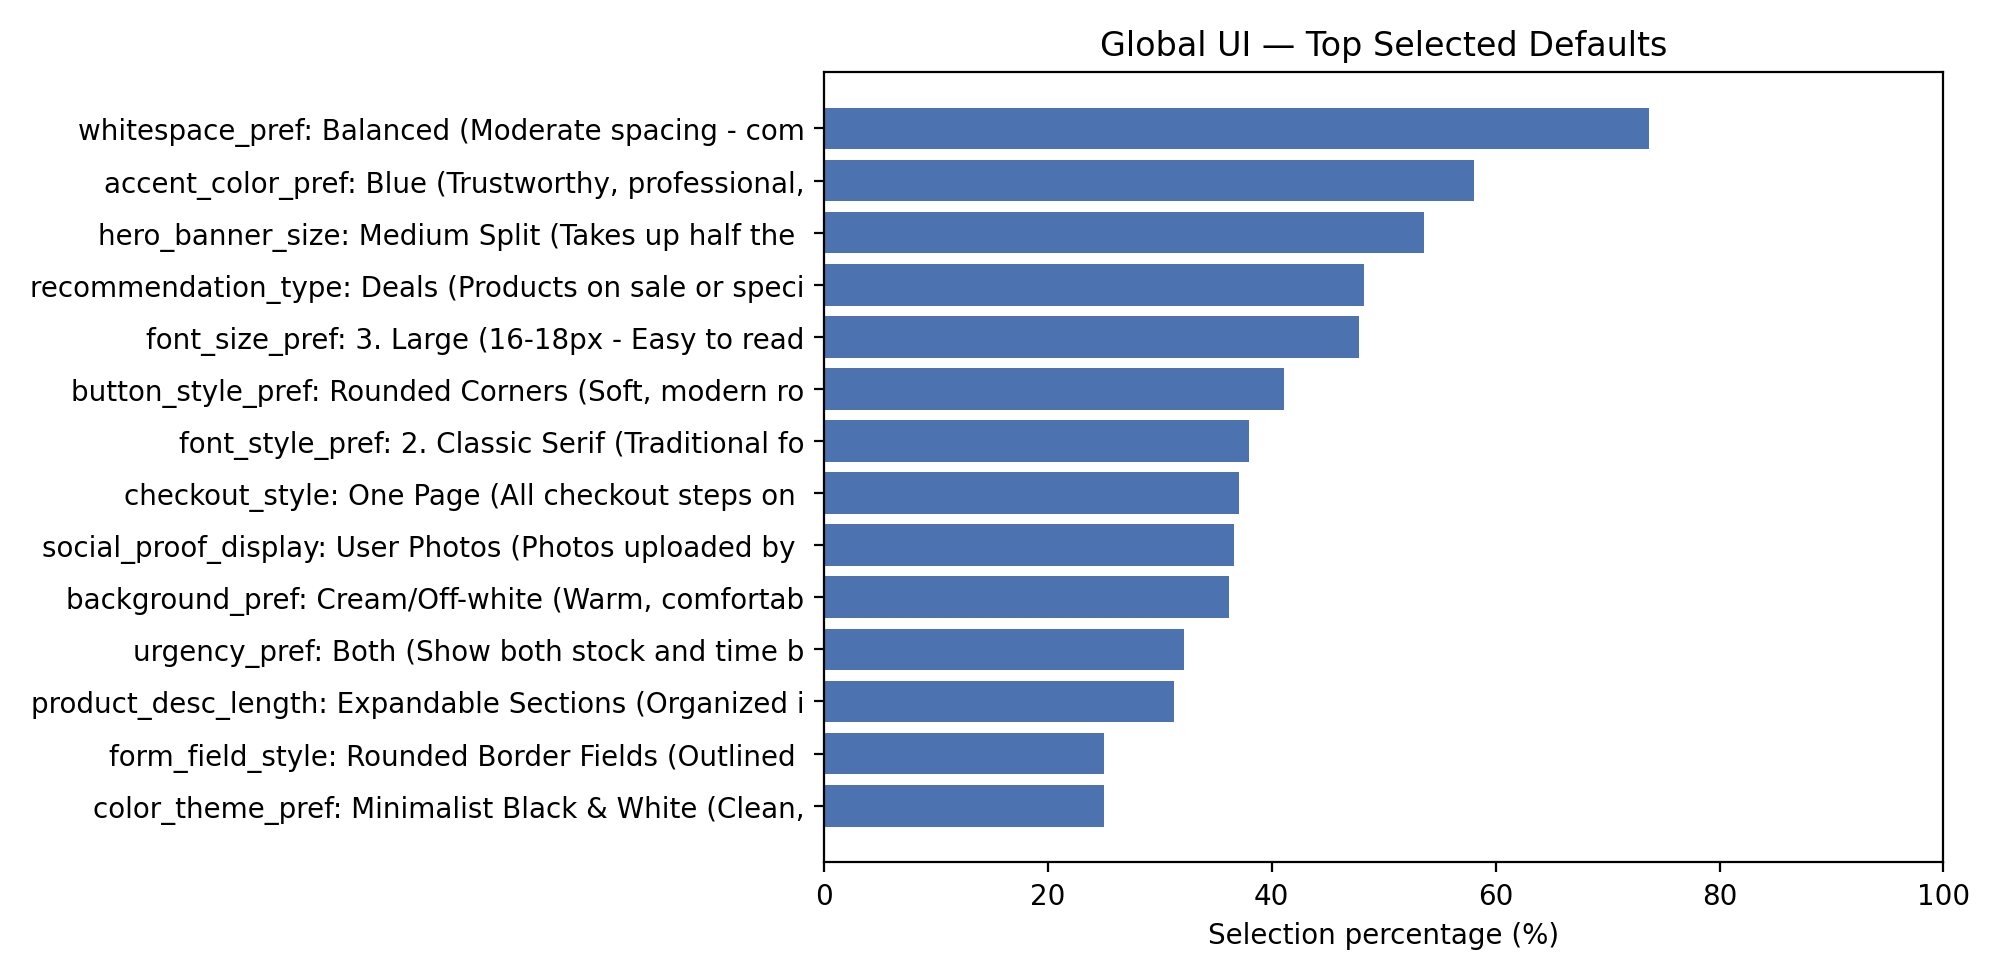

desktop_top_selected_options.png


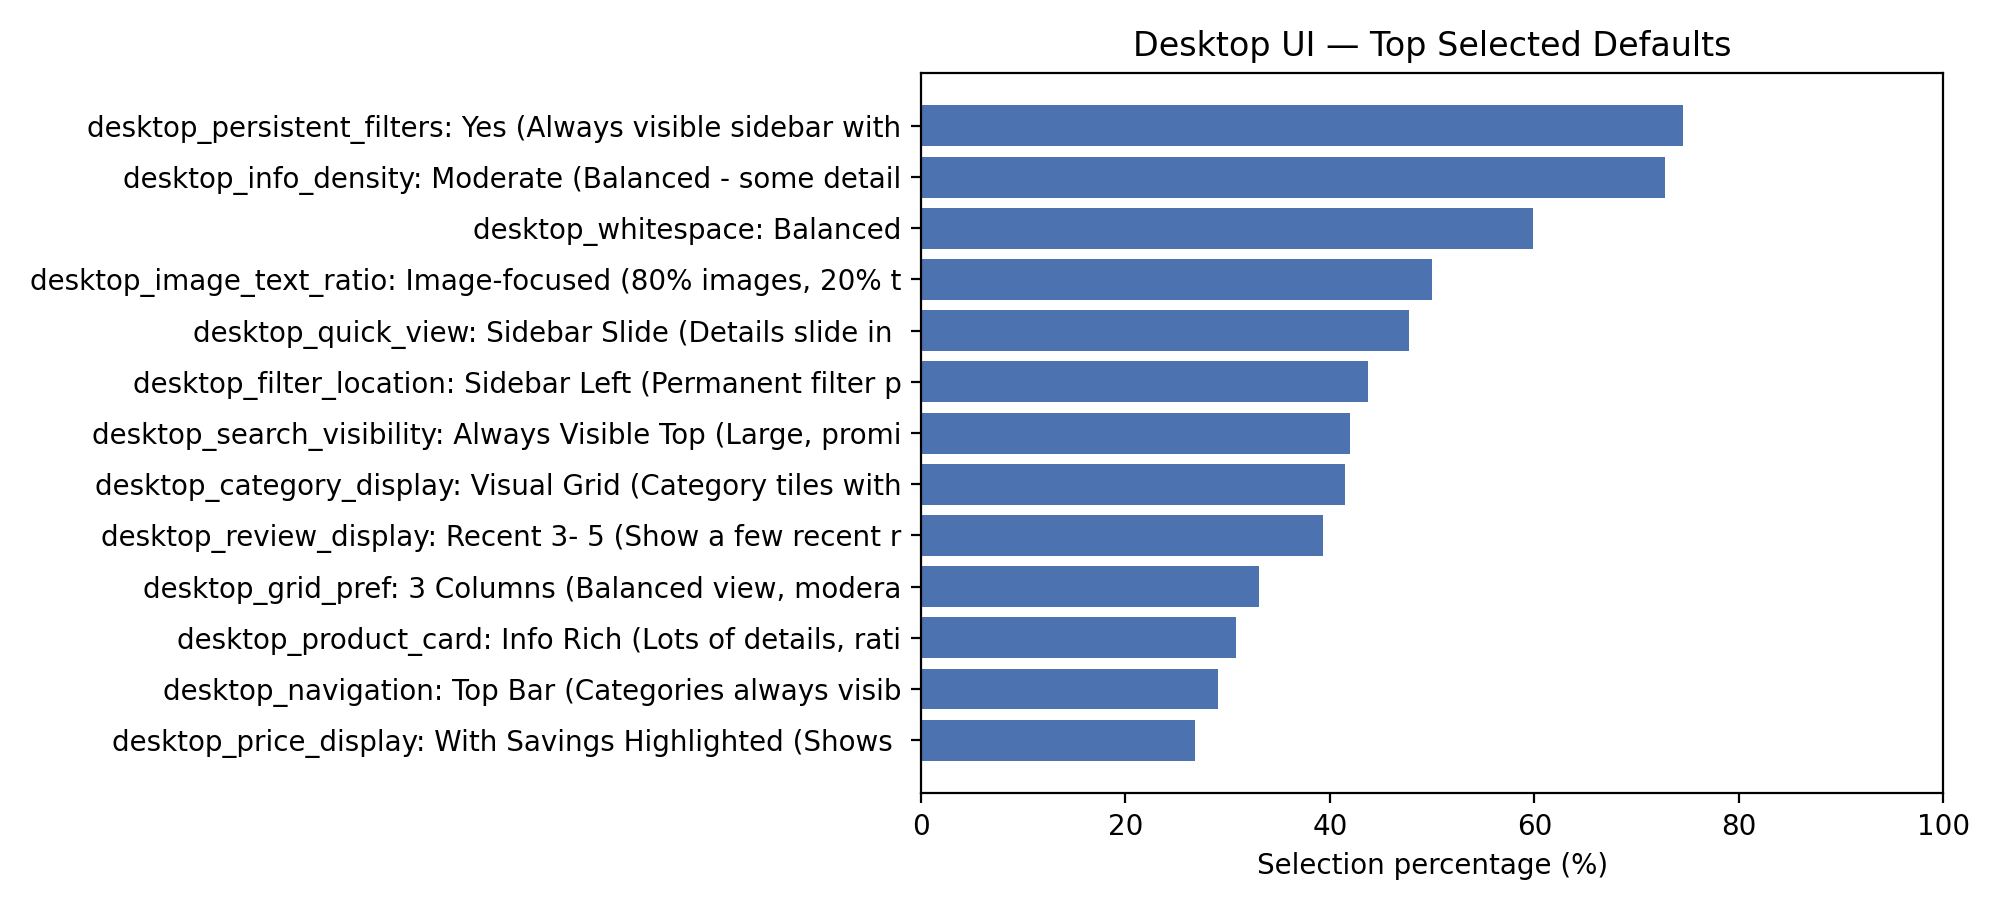

mobile_top_selected_options.png


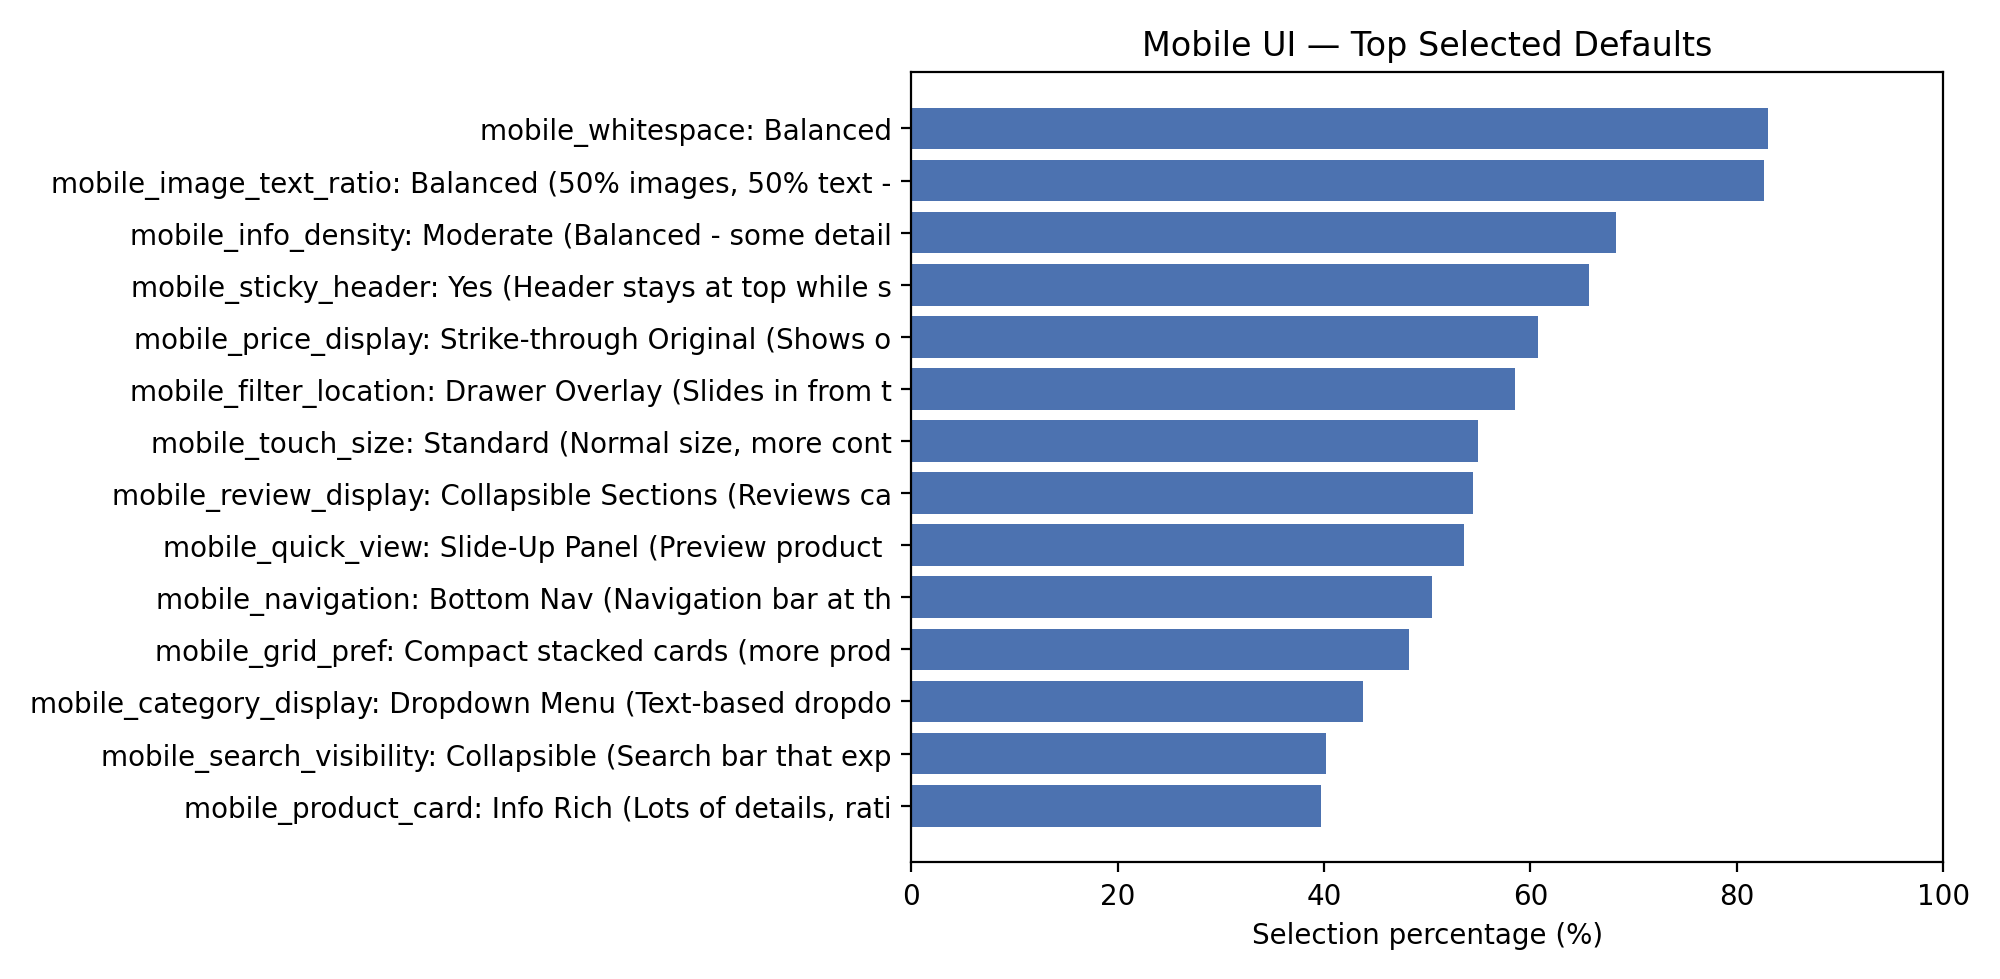

global_strongest_distribution.png


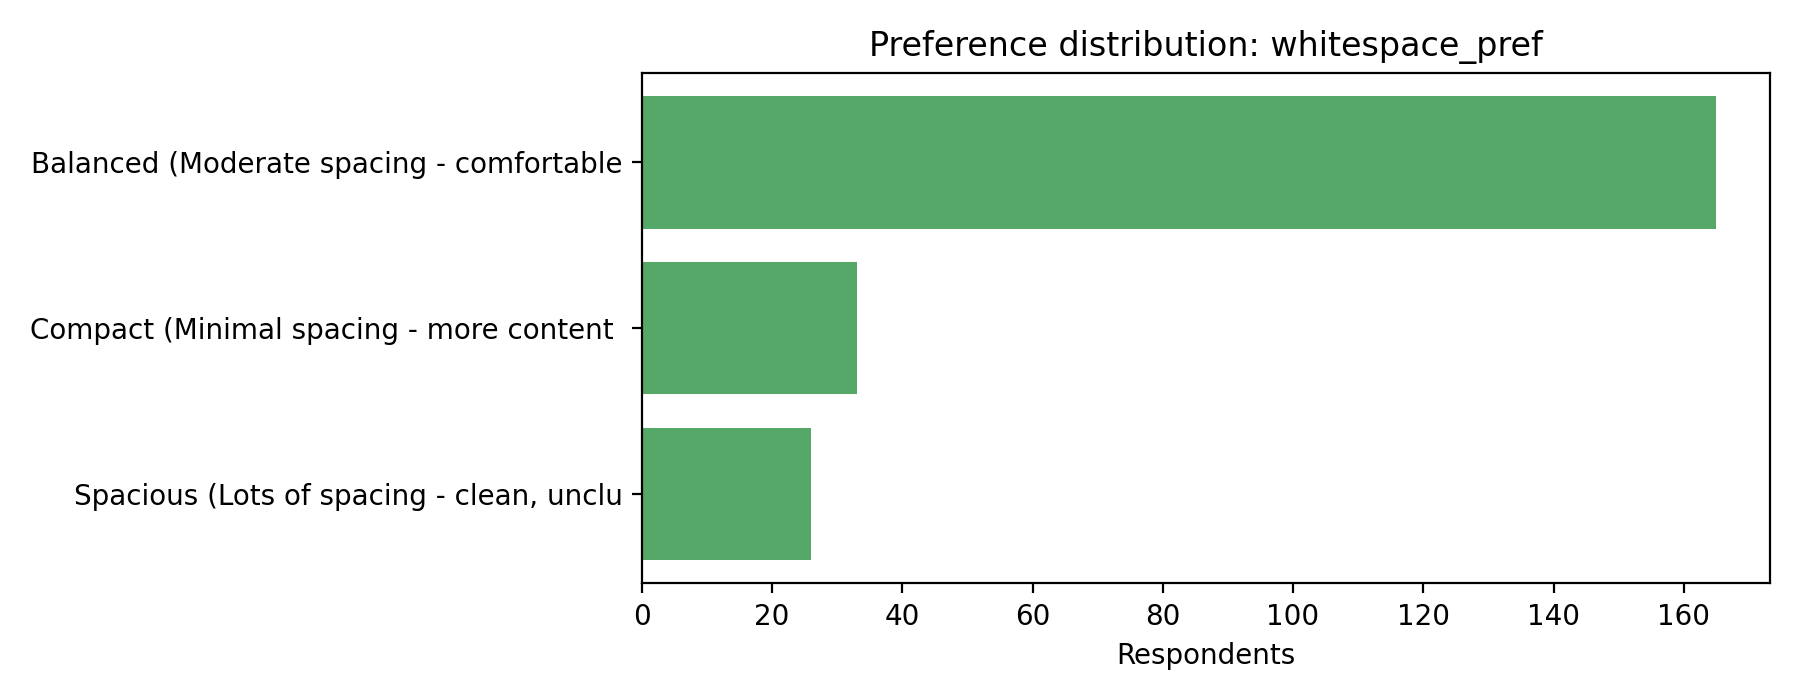

desktop_strongest_distribution.png


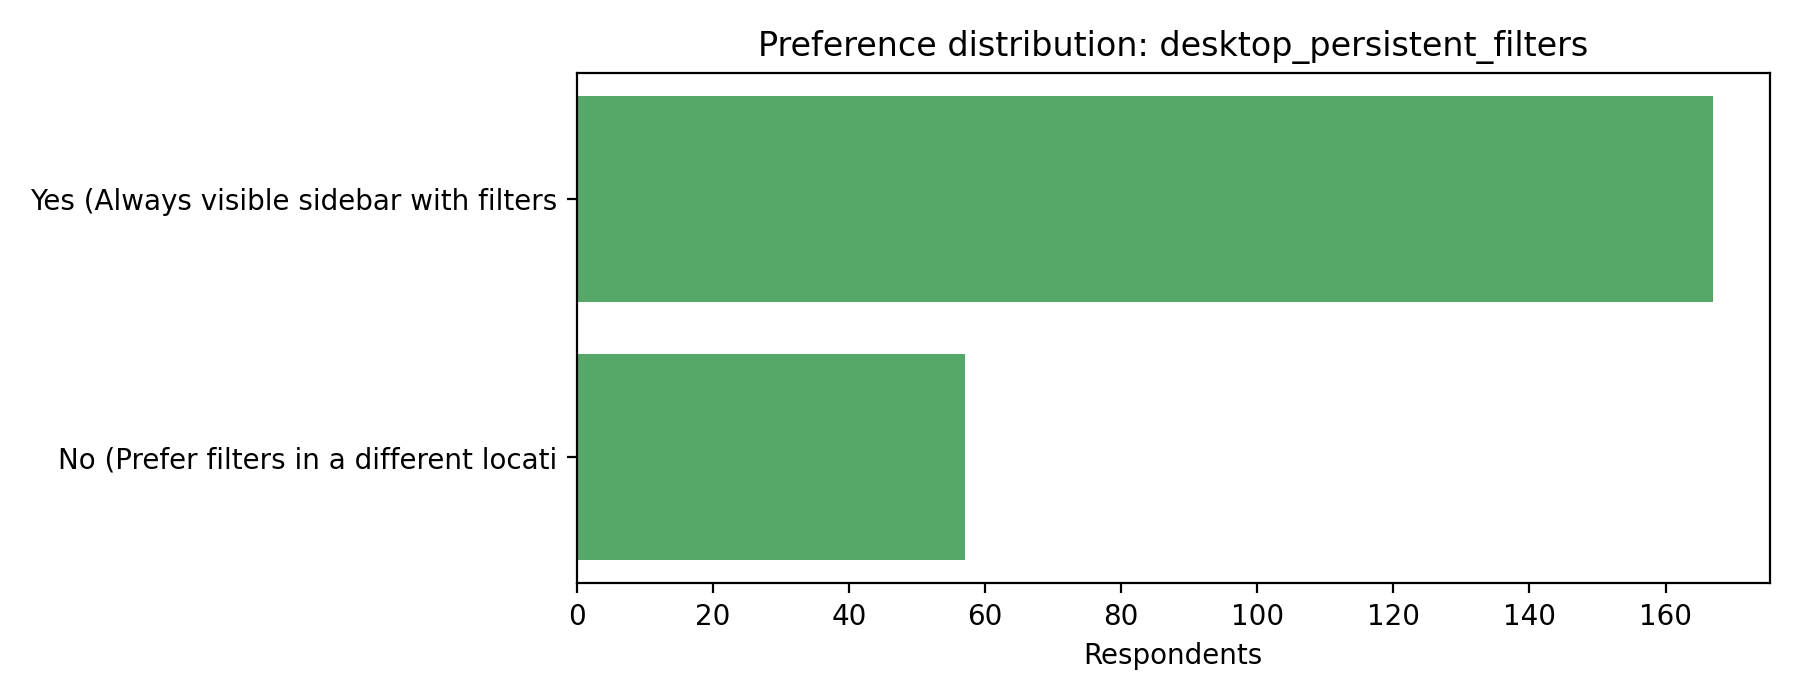

mobile_strongest_distribution.png


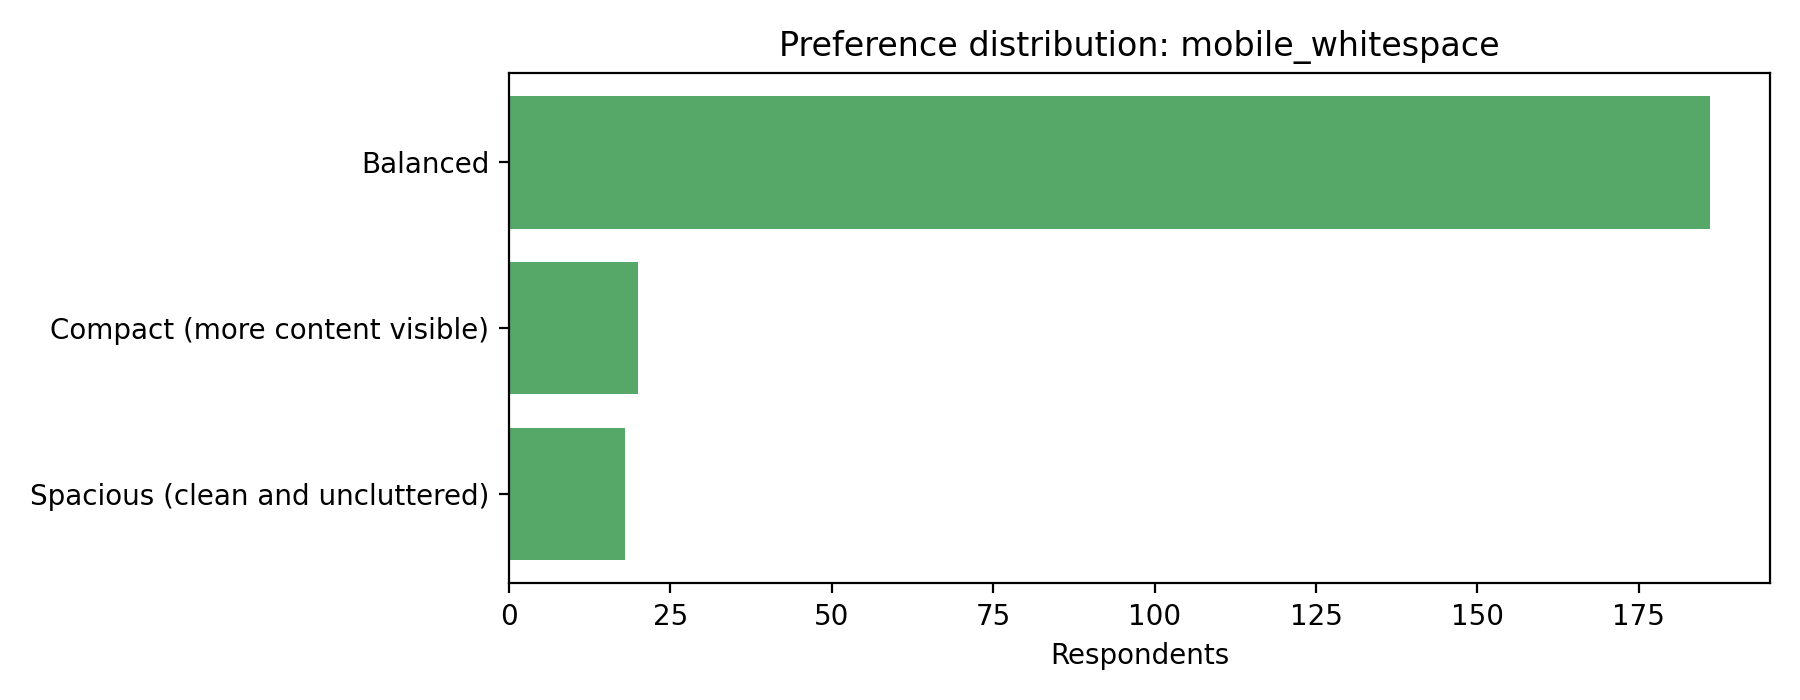

In [5]:
from IPython.display import Image, display as ipy_display

figures_dir = REPORTS / "figures"
for figure_name in [
    "global_top_selected_options.png",
    "desktop_top_selected_options.png",
    "mobile_top_selected_options.png",
    "global_strongest_distribution.png",
    "desktop_strongest_distribution.png",
    "mobile_strongest_distribution.png",
]:
    figure_path = figures_dir / figure_name
    if figure_path.exists():
        print(figure_name)
        ipy_display(Image(filename=str(figure_path)))

## Exports

In [6]:
print("Export locations:")
for name, path in result.export_paths.items():
    print(f"- {name}: {path}")

Export locations:
- global_defaults_json: /Users/mariam/Downloads/New_Master copy/smartshop/EvidenceBasedAdaptiveUI/data/outputs/global_defaults.json
- global_defaults_xlsx: /Users/mariam/Downloads/New_Master copy/smartshop/EvidenceBasedAdaptiveUI/reports/DefaultUI/global_defaults.xlsx
- global_defaults_csv: /Users/mariam/Downloads/New_Master copy/smartshop/EvidenceBasedAdaptiveUI/reports/DefaultUI/global_defaults.csv
- desktop_defaults_json: /Users/mariam/Downloads/New_Master copy/smartshop/EvidenceBasedAdaptiveUI/data/outputs/desktop_defaults.json
- desktop_defaults_xlsx: /Users/mariam/Downloads/New_Master copy/smartshop/EvidenceBasedAdaptiveUI/reports/DefaultUI/desktop_defaults.xlsx
- desktop_defaults_csv: /Users/mariam/Downloads/New_Master copy/smartshop/EvidenceBasedAdaptiveUI/reports/DefaultUI/desktop_defaults.csv
- mobile_defaults_json: /Users/mariam/Downloads/New_Master copy/smartshop/EvidenceBasedAdaptiveUI/data/outputs/mobile_defaults.json
- mobile_defaults_xlsx: /Users/maria

## Final Output

In [7]:
print(f"Global variables: {result.summary['global_variables']}")
print(f"Desktop variables: {result.summary['desktop_variables']}")
print(f"Mobile variables: {result.summary['mobile_variables']}")
print("Repository generated successfully.")

Global variables: 14
Desktop variables: 13
Mobile variables: 14
Repository generated successfully.
